# Quickstart

https://lifelines.readthedocs.io/en/latest/Quickstart.html

In [ ]:
from lifelines.datasets import load_waltons
from lifelines import KaplanMeierFitter
from lifelines.utils import median_survival_times
import matplotlib.pyplot as plt
import numpy as np
from lifelines import *
from lifelines import NelsonAalenFitter
from lifelines.utils import datetimes_to_durations
from lifelines.utils import survival_table_from_events
from lifelines.datasets import load_regression_dataset
from lifelines import CoxPHFitter
from lifelines import WeibullAFTFitter
from lifelines import AalenAdditiveFitter



In [2]:
df = load_waltons() # returns a Pandas DataFrame

print(df.head())
T = df['T']
E = df['E']

      T  E    group
0   6.0  1  miR-137
1  13.0  1  miR-137
2  13.0  1  miR-137
3  13.0  1  miR-137
4  19.0  1  miR-137


In [3]:
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E)  # or, more succinctly, kmf.fit(T, E)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 163 total observations, 7 right-censored observations>

<Axes: xlabel='timeline'>

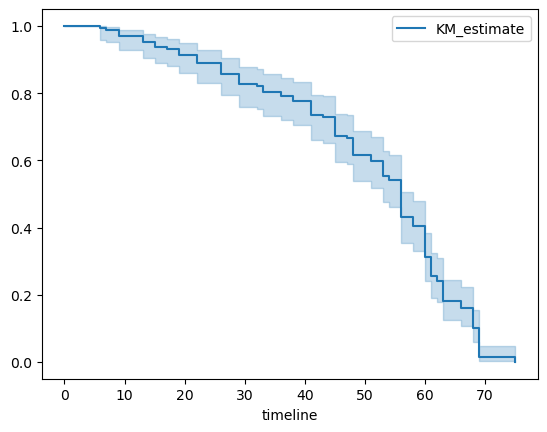

In [4]:
kmf.survival_function_
kmf.cumulative_density_
kmf.plot_survival_function()

<Axes: xlabel='timeline'>

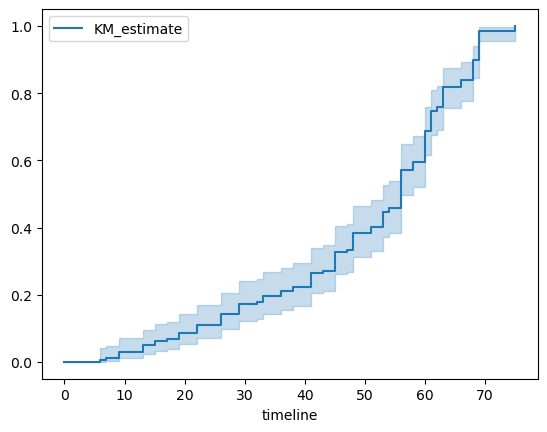

In [5]:
kmf.plot_cumulative_density()


In [6]:
kmf.fit(T, E, timeline=range(0, 100, 2))

kmf.survival_function_   # index is now the same as range(0, 100, 2)
kmf.confidence_interval_ # index is now the same as range(0, 100, 2)

,KM_estimate_lower_0.95,KM_estimate_upper_0.95
0.0,1.000000,1.000000
2.0,1.000000,1.000000
4.0,1.000000,1.000000
6.0,0.957254,0.999134
8.0,0.951834,0.996917
10.0,0.927613,0.987068
12.0,0.927613,0.987068
14.0,0.903821,0.975031
16.0,0.888437,0.966342
18.0,0.880865,0.961853


In [ ]:

median_ = kmf.median_survival_time_
median_confidence_interval_ = median_survival_times(kmf.confidence_interval_)

<Axes: >

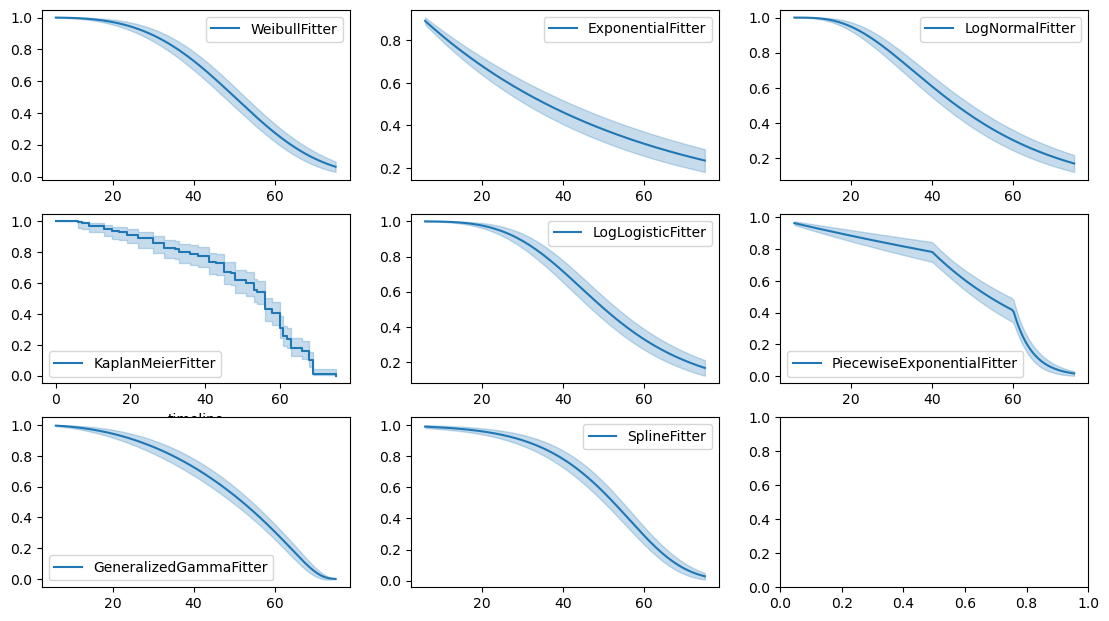

In [ ]:


fig, axes = plt.subplots(3, 3, figsize=(13.5, 7.5))

kmf = KaplanMeierFitter().fit(T, E, label='KaplanMeierFitter')
wbf = WeibullFitter().fit(T, E, label='WeibullFitter')
exf = ExponentialFitter().fit(T, E, label='ExponentialFitter')
lnf = LogNormalFitter().fit(T, E, label='LogNormalFitter')
llf = LogLogisticFitter().fit(T, E, label='LogLogisticFitter')
pwf = PiecewiseExponentialFitter([40, 60]).fit(T, E, label='PiecewiseExponentialFitter')
ggf = GeneralizedGammaFitter().fit(T, E, label='GeneralizedGammaFitter')
sf = SplineFitter(np.percentile(T.loc[E.astype(bool)], [0, 50, 100])).fit(T, E, label='SplineFitter')

wbf.plot_survival_function(ax=axes[0][0])
exf.plot_survival_function(ax=axes[0][1])
lnf.plot_survival_function(ax=axes[0][2])
kmf.plot_survival_function(ax=axes[1][0])
llf.plot_survival_function(ax=axes[1][1])
pwf.plot_survival_function(ax=axes[1][2])
ggf.plot_survival_function(ax=axes[2][0])
sf.plot_survival_function(ax=axes[2][1])

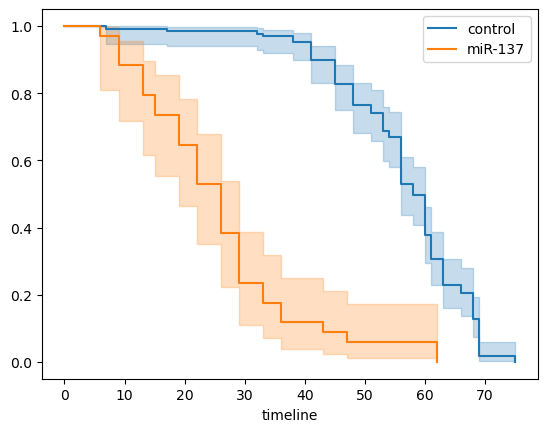

In [9]:
groups = df['group']
ix = (groups == 'miR-137')

kmf.fit(T[~ix], E[~ix], label='control')
ax = kmf.plot_survival_function()

kmf.fit(T[ix], E[ix], label='miR-137')
ax = kmf.plot_survival_function(ax=ax)


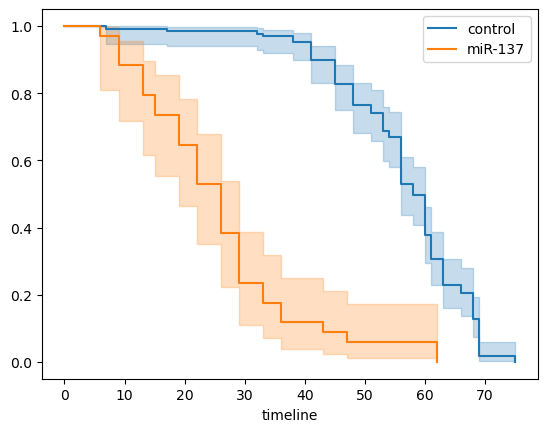

In [10]:
ax = plt.subplot(111)

kmf = KaplanMeierFitter()

for name, grouped_df in df.groupby('group'):
    kmf.fit(grouped_df["T"], grouped_df["E"], label=name)
    kmf.plot_survival_function(ax=ax)

In [ ]:
naf = NelsonAalenFitter()
naf.fit(T, event_observed=E)

<lifelines.NelsonAalenFitter:"NA_estimate", fitted with 163 total observations, 7 right-censored observations>

## Getting data in the right format

In [ ]:

# start_times is a vector or list of datetime objects or datetime strings
# end_times is a vector or list of (possibly missing) datetime objects or datetime strings
T, E = datetimes_to_durations(start_times, end_times, freq='h')

In [ ]:

table = survival_table_from_events(T, E)
print(table.head())

## Survival regression

In [ ]:
regression_dataset = load_regression_dataset() # a Pandas DataFrame

<lifelines.CoxPHFitter: fitted with 200 total observations, 11 right-censored observations>
             duration col = 'T'
                event col = 'E'
      baseline estimation = breslow
   number of observations = 200
number of events observed = 189
   partial log-likelihood = -807.62
         time fit was run = 2025-10-15 18:58:54 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
var1       0.22      1.25      0.07            0.08            0.37                1.08                1.44
var2       0.05      1.05      0.08           -0.11            0.21                0.89                1.24
var3       0.22      1.24      0.08            0.07            0.37                1.07                1.44

           cmp to    z      p  -log2(p)
covariate                              
var1         0.00 2.99 <0.005      8.49
var2         0.00 0.61   0.54      0.89
var3         0.00 2.88 <0.005      7.97
---
Concordance = 0.58
Partial AIC = 1621.24
log-likelihood ratio test = 15.54 on 3 df
-log2(p) of ll-ratio test = 9.47

<Axes: xlabel='log(HR) (95% CI)'>

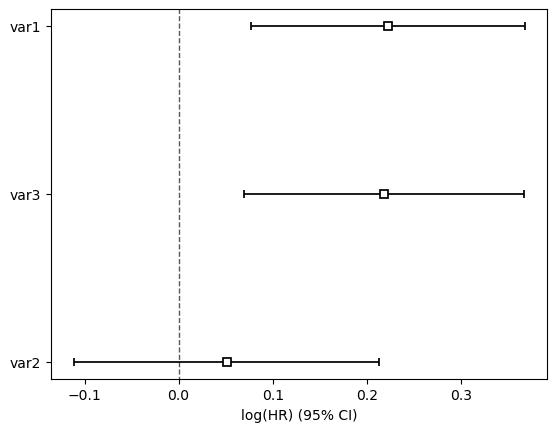

In [ ]:

# Using Cox Proportional Hazards model
cph = CoxPHFitter()
cph.fit(regression_dataset, 'T', event_col='E')
cph.print_summary()

cph.plot()

<lifelines.WeibullAFTFitter: fitted with 200 total observations, 11 right-censored observations>
             duration col = 'T'
                event col = 'E'
   number of observations = 200
number of events observed = 189
           log-likelihood = -504.48
         time fit was run = 2025-10-15 18:59:11 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                  
lambda_ var1      -0.08      0.92      0.02           -0.13           -0.04                0.88                0.97
        var2      -0.02      0.98      0.03           -0.07            0.04                0.93                1.04
        var3      -0.08      0.92      0.02           -0.13           -0.03                0.88                0.97
        Intercept  2.53     12.57      0.05            2.43            2.63               11.41               13.85
rho_    Intercept  1.09      2.98      0.05            0.99            1.20                2.68                3.32

                   cmp to     z      p  -log2(p)
param   covariate                               
lambda_ var1         0.00 -3.45 <0.005     10.78
        var2         0.00 -0.56   0.57      0.80
        var3         0.00 -3.33 <0.005     10.15
        Intercept    0.00 51.12 <0.005       inf
rho_    Intercept    0.00 20.12 <0.005    296.66
---
Concordance = 0.58
AIC = 1018.97
log-likelihood ratio test = 19.73 on 3 df
-log2(p) of ll-ratio test = 12.34

<Axes: xlabel='log(accelerated failure rate) (95% CI)'>

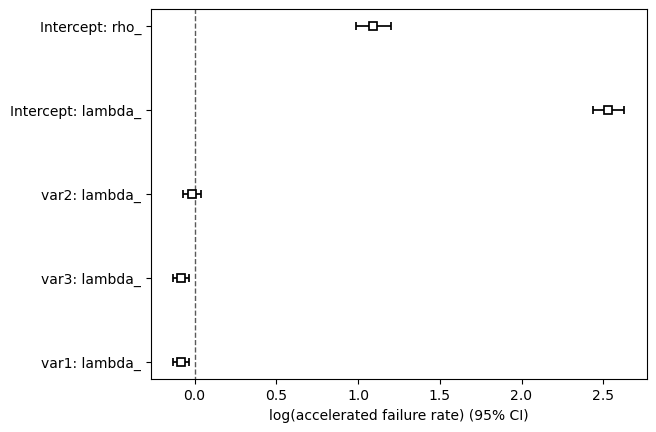

In [ ]:

wft = WeibullAFTFitter()
wft.fit(regression_dataset, 'T', event_col='E')
wft.print_summary()

wft.plot()

In [ ]:
# Using Aalen's Additive model
aaf = AalenAdditiveFitter(fit_intercept=False)
aaf.fit(regression_dataset, 'T', event_col='E')

<lifelines.AalenAdditiveFitter: fitted with 200 total observations, 11 right-censored observations>

<Axes: >

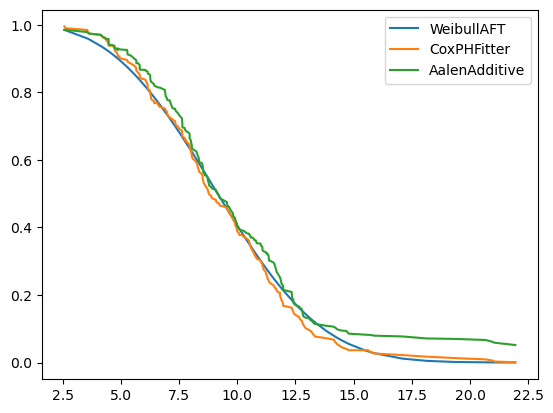

In [18]:
X = regression_dataset.loc[0]

ax = wft.predict_survival_function(X).rename(columns={0:'WeibullAFT'}).plot()
cph.predict_survival_function(X).rename(columns={0:'CoxPHFitter'}).plot(ax=ax)
aaf.predict_survival_function(X).rename(columns={0:'AalenAdditive'}).plot(ax=ax)